<a href="https://colab.research.google.com/github/kuroshkarimi/Machine-Learning-and-Data-Analysis/blob/main/Deep_Learning_Regression/Weather_Forcast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Project task definition


**Jena Climate: 24-Hour Temperature Forecasting with 1D CNN.**


The Jena Climate dataset contains meteorological measurements recorded approximately every 10 minutes at the Max Planck Institute for Biogeochemistry in Jena, Germany. The dataset includes 14 weather variables such as temperature, atmospheric pressure, humidity, wind speed, and vapor pressure.

The objective is to build a multivariate time-series regression model that uses the previous 72 hours of weather measurements to predict the temperature for each of the following 24 hours.

After converting the measurements to hourly intervals:

Each input sample has 72 time steps.
Each time step contains 14 weather features.
Each target contains 24 temperature values.
The model is evaluated using MAE, RMSE, and R2.

The data must be divided chronologically into training, validation, and test sets.
Normalization parameters must be calculated using only the training data.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from keras.models import Sequential
from keras.layers import (
    Activation,
    Input,
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Reading the data

zip_path = tf.keras.utils.get_file(
    origin = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname = 'jena_climate_2009_2016.csv.zip',
    extract = True
)

# The zip_path now points to the extracted directory.
# We need to construct the full path to the CSV file inside that directory.
csv_path = os.path.join(zip_path, 'jena_climate_2009_2016.csv')
df1 = pd.read_csv(csv_path)

df1.head()

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [3]:
# Taking a glance into the gernal characteristics of the data

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  object 
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10  H2OC (mmol/mol)  420551 non-null  float64
 11  rho (g/m**3)     420551 non-null  float64
 12  wv (m/s)         420551 non-null  float64
 13  max. wv (m/s)    420551 non-null  float64
 14  wd (deg)         420551 non-null  float64
dtypes: float64(14), object(1)
memory usage: 48.1+ MB


In [4]:
df1.describe()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000
mean,989.212776,9.450147,283.492743,4.955854,76.008259,13.576251,9.533756,4.042412,6.022408,9.640223,1216.062748,1.702224,3.056555,174.743738
std,8.358481,8.423365,8.504471,6.730674,16.476175,7.739020,4.184164,4.896851,2.656139,4.235395,39.975208,65.446714,69.016932,86.681693
min,913.600000,-23.010000,250.600000,-25.010000,12.950000,0.950000,0.790000,0.000000,0.500000,0.800000,1059.450000,-9999.000000,-9999.000000,0.000000
25%,984.200000,3.360000,277.430000,0.240000,65.210000,7.780000,6.210000,0.870000,3.920000,6.290000,1187.490000,0.990000,1.760000,124.900000
50%,989.580000,9.420000,283.470000,5.220000,79.300000,11.820000,8.860000,2.190000,5.590000,8.960000,1213.790000,1.760000,2.960000,198.100000
75%,994.720000,15.470000,289.530000,10.070000,89.400000,17.600000,12.350000,5.300000,7.800000,12.490000,1242.770000,2.860000,4.740000,234.100000
max,1015.350000,37.280000,311.340000,23.110000,100.000000,63.770000,28.320000,46.010000,18.130000,28.820000,1393.540000,28.490000,23.500000,360.000000


In [5]:
extreme_max_wv = df1[df1['max. wv (m/s)'] == -9999].index
print(extreme_max_wv)

extreme_wv = df1[df1['wv (m/s)'] == -9999].index
print(extreme_wv)

Index([343577, 343578, 343579, 343580, 343581, 343582, 343583, 343584, 343585,
       343586, 343587, 343588, 343589, 343590, 343591, 343592, 343593, 343594,
       343595, 343596],
      dtype='int64')
Index([343578, 343579, 343580, 343581, 343582, 343583, 343584, 343585, 343586,
       343587, 343588, 343589, 343590, 343591, 343592, 343593, 343594, 343595],
      dtype='int64')


In [6]:
df1['wv (m/s)'].replace(-9999.000000, 0.000000, inplace = True)
df1['max. wv (m/s)'].replace(-9999.000000, 0.000000, inplace = True)

/tmp/ipykernel_1267/1609697072.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['wv (m/s)'].replace(-9999.000000, 0.000000, inplace = True)
/tmp/ipykernel_1267/1609697072.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [7]:
# The data shows 14 parameters every 6 minutes. We down sample it to every 1 hour
df = df1.iloc[::6].reset_index(drop = True)
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 01:10:00,996.50,-7.62,265.81,-8.30,94.8,3.44,3.26,0.18,2.04,3.27,1305.68,0.18,0.63,166.5
2,01.01.2009 02:10:00,996.63,-8.85,264.57,-9.70,93.5,3.12,2.92,0.20,1.82,2.93,1312.11,0.16,0.50,158.3
3,01.01.2009 03:10:00,996.87,-8.84,264.56,-9.69,93.5,3.13,2.92,0.20,1.83,2.93,1312.37,0.07,0.25,129.3
4,01.01.2009 04:10:00,997.05,-9.23,264.15,-10.25,92.2,3.03,2.79,0.24,1.74,2.80,1314.62,0.10,0.38,203.9


In [8]:
df.drop(['Date Time'], axis = 1, inplace = True)


In [9]:
# Splitting the data into train, validation and test pieces with keeping the chronological order.
data = df.values
n = data.shape[0]
n1 = int(n * 0.7)
n2 = int(n * 0.85)


train = data[: n1, :]
validation = data[n1: n2, :]
test = data[n2:, :]

print(train.shape, validation.shape, test.shape)


(49064, 14) (10514, 14) (10514, 14)


In [25]:
mean = train.mean(axis = 0, keepdims = True)
std = train.std(axis = 0, keepdims = True)
print(mean.shape)
print(std.shape)
norm_train = (train - mean) / std
norm_validation = (validation - mean) / std
norm_test = (test - mean) / std



(1, 14)
(1, 14)


In [11]:
def make_windows(data, target_col, input_width, horizon):
    '''
    make_windows creates overlapping windows

    data is the original data set with shape = n_time_steps, n_features
      for example here, we have 7000 time steps and 14 features

    target_col is the index of the column we want to predict its values

    input_width is the length of each input sequence

    horizon tells the function how far into the future you want to predict

    start and end specify which part of the time series we want to use
    '''
    X = []
    y = []

    last_start = len(data) - input_width - horizon

    for start in np.arange(0, last_start + 1):
        input_end = start + input_width
        target_end = input_end + horizon

        input_window = data[start:input_end]

        target_window = data[
            input_end:target_end,
            target_col
        ]

        X.append(input_window)
        y.append(target_window)

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32)
    )

In [12]:
input_width = 72
horizon = 24

X_train, y_train = make_windows(
    data = norm_train,
    target_col = 1, #  1 (index for 'T (degC)')
    input_width = input_width,
    horizon = horizon,
)

X_validation, y_validation = make_windows(
    data = norm_validation,
    target_col = 1,
    input_width = input_width,
    horizon = horizon
)



X_test, y_test = make_windows(
    data = norm_test,
    target_col = 1,
    input_width = input_width,
    horizon = horizon
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_validation.shape)
print("y_val:", y_validation.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (48969, 72, 14)
y_train: (48969, 24)
X_val: (10419, 72, 14)
y_val: (10419, 24)
X_test: (10419, 72, 14)
y_test: (10419, 24)


In [13]:
# Creating the model
n_features = X_train.shape[2]


from keras.layers import Flatten

model = Sequential([
    Input(shape=(input_width, n_features)),

    Conv1D(32, 5, padding="causal", activation="relu"),
    MaxPooling1D(2),

    Conv1D(64, 3, padding="causal", activation="relu"),
    MaxPooling1D(2),

    Flatten(),

    Dense(64, activation="relu"),
    Dropout(0.30),

    Dense(horizon)
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 72, 32)         │         2,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 36, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 36, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 18, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,832 (327.47 KB)

 Trainable params: 83,832 (327.47 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    loss ='mse',
    optimizer = Adam(learning_rate = 3e-4),
    metrics = ['mae']
)

In [15]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)



In [16]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=100,
    batch_size=128,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    shuffle=True,
    verbose=1
)

Epoch 1/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - loss: 0.3264 - mae: 0.4311 - val_loss: 0.1314 - val_mae: 0.2818 - learning_rate: 3.0000e-04
Epoch 2/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 0.1767 - mae: 0.3249 - val_loss: 0.1133 - val_mae: 0.2607 - learning_rate: 3.0000e-04
Epoch 3/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 0.1470 - mae: 0.2964 - val_loss: 0.1033 - val_mae: 0.2477 - learning_rate: 3.0000e-04
Epoch 4/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.1315 - mae: 0.2804 - val_loss: 0.1025 - val_mae: 0.2454 - learning_rate: 3.0000e-04
Epoch 5/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.1223 - mae: 0.2704 - val_loss: 0.0983 - val_mae: 0.2409 - learning_rate: 3.0000e-04
Epoch 6/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.1155 - mae: 0.2626 - val_loss: 0.0966 - val_mae: 0.2387 - learning_rate: 3.0000e-04
Epoch 7/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.1112 - mae: 0.2573 - val_loss: 0.0966 - val

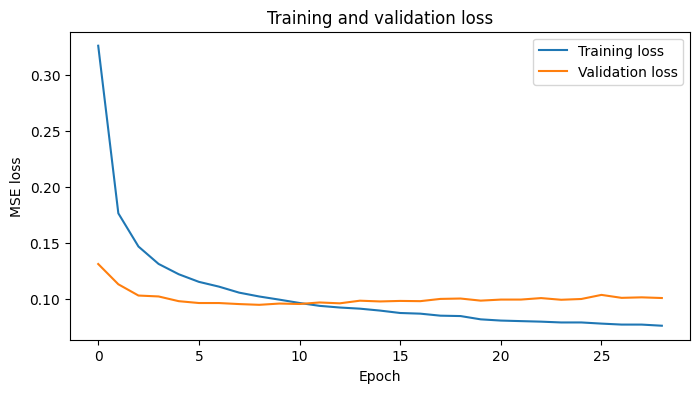

In [31]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.title("Training and validation loss")
plt.show()

In [32]:
# Prediction of the test data

y_pred_norm = model.predict(X_test)
print(y_pred_norm.shape)

326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
(10419, 24)


In [33]:
# since y_pred and y_test are both normalized values, they should revert to
# the original scale using the standard deviation and mean of the first
# column of the data related to the temperature.

y_test_original = std[0, 1] * y_test + mean[0, 1]
y_pred = std[0, 1] * y_pred_norm + mean[0, 1]

In [35]:
# Calculation of the error metrics

mae = mean_absolute_error(y_test_original, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))
r2 = r2_score(y_test_original, y_pred)

print(f"Test MAE:  {mae:.3f} °C")
print(f"Test RMSE: {rmse:.3f} °C")
print(f"Test R²:   {r2:.3f}")

Test MAE:  1.995 °C
Test RMSE: 2.579 °C
Test R²:   0.891
